In [62]:
from warnings import simplefilter
simplefilter(action='ignore')
import numpy as np 
import pandas as pd
import missingno as msno

In [63]:
df = pd.read_parquet('house_model_base.parquet')

In [64]:
display(df.info(), df.columns, df.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 8572 entries, 0 to 8571
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CAND_ID                 8572 non-null   str    
 1   CYCLE                   8572 non-null   int64  
 2   STATE                   8572 non-null   str    
 3   DISTRICT                8572 non-null   int64  
 4   CAND_NAME_FIRST         8572 non-null   str    
 5   CAND_NAME_LAST          8572 non-null   str    
 6   CAND_NAME               8572 non-null   str    
 7   RESULTS_PARTY           8572 non-null   str    
 8   CAND_PTY_AFFILIATION    8569 non-null   str    
 9   CAND_ICI                8568 non-null   str    
 10  OUTCOME                 8572 non-null   int64  
 11  UNOPPOSED               8572 non-null   bool   
 12  VOTES                   8536 non-null   float64
 13  VOTE_SHARE              8572 non-null   float64
 14  TTL_RECEIPTS            8572 non-null   float64
 15

None

Index(['CAND_ID', 'CYCLE', 'STATE', 'DISTRICT', 'CAND_NAME_FIRST',
       'CAND_NAME_LAST', 'CAND_NAME', 'RESULTS_PARTY', 'CAND_PTY_AFFILIATION',
       'CAND_ICI', 'OUTCOME', 'UNOPPOSED', 'VOTES', 'VOTE_SHARE',
       'TTL_RECEIPTS', 'TRANS_FROM_AUTH', 'TTL_DISB', 'TRANS_TO_AUTH',
       'COH_COP', 'CAND_CONTRIB', 'CAND_LOANS', 'TTL_INDIV_CONTRIB',
       'OTHER_POL_CMTE_CONTRIB', 'POL_PTY_CONTRIB'],
      dtype='str')

,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,TTL_RECEIPTS,TRANS_FROM_AUTH,TTL_DISB,TRANS_TO_AUTH,COH_COP,CAND_CONTRIB,CAND_LOANS,TTL_INDIV_CONTRIB,OTHER_POL_CMTE_CONTRIB,POL_PTY_CONTRIB
0,H6AK00045,2004,AK,0,Alvin A.,Anders,"YOUNG, DON E",LBT,REP,I,...,2482935.36,0.0,1747901.68,162500.0,1898567.49,0.00,0.0,1491130.73,928658.63,392.00
1,H2AL01119,2004,AL,1,Judy,Belk,"BELK, JUDY MCCAIN",DEM,DEM,C,...,465473.41,0.0,529989.34,0.0,438.60,176665.27,75600.0,124177.72,74430.20,14050.00
2,H2AL01077,2004,AL,1,Jo,Bonner,"BONNER, JOSIAH ROBINS JR.",REP,REP,I,...,1180895.09,0.0,1015709.13,0.0,178261.99,0.00,0.0,778293.95,394355.71,750.00
3,H4AL02063,2004,AL,2,Charles D. (Chuck),James,"JAMES, CHARLES DEAN",DEM,DEM,C,...,1320.00,0.0,1320.00,0.0,0.00,0.00,1259.0,1640.00,0.00,1000.00
4,H2AL02067,2004,AL,2,Terry,Everett,"EVERETT, TERRY",REP,REP,I,...,2001444.50,0.0,1937044.18,0.0,281717.43,0.00,530173.0,439265.74,336616.98,6036.30
5,H4AL03046,2004,AL,3,Bill,Fuller,"FULLER, BILL",DEM,DEM,C,...,280238.21,0.0,240776.56,0.0,30260.89,0.00,0.0,162038.21,115700.00,2500.00
6,H2AL03032,2004,AL,3,Mike,Rogers,"ROGERS, MICHAEL",REP,REP,I,...,2121838.37,0.0,1893594.35,0.0,246299.64,0.00,0.0,1194102.11,818567.58,75460.36
7,H4AL04028,2004,AL,4,Carl,Cole,"COLE, CARL ALLEN III",DEM,DEM,C,...,25553.50,0.0,25497.29,0.0,56.21,0.00,0.0,23303.50,1500.00,750.00
8,H6AL04098,2004,AL,4,Robert,Aderholt,"ADERHOLT, ROBERT B",REP,REP,I,...,748913.55,0.0,735358.06,0.0,168519.19,0.00,0.0,405913.78,255700.00,18.39
9,H0AL05049,2004,AL,5,Bud,Cramer,"CRAMER, ROBERT EDWARD BUD JR",DEM,DEM,I,...,820380.72,0.0,588843.11,8000.0,1325123.73,0.00,0.0,391908.17,403467.07,0.00


CAND_ID                    0
CYCLE                      0
STATE                      0
DISTRICT                   0
CAND_NAME_FIRST            0
CAND_NAME_LAST             0
CAND_NAME                  0
RESULTS_PARTY              0
CAND_PTY_AFFILIATION       3
CAND_ICI                   4
OUTCOME                    0
UNOPPOSED                  0
VOTES                     36
VOTE_SHARE                 0
TTL_RECEIPTS               0
TRANS_FROM_AUTH            0
TTL_DISB                   0
TRANS_TO_AUTH              0
COH_COP                    0
CAND_CONTRIB               0
CAND_LOANS                 0
TTL_INDIV_CONTRIB          0
OTHER_POL_CMTE_CONTRIB     0
POL_PTY_CONTRIB            0
dtype: int64

<Axes: >

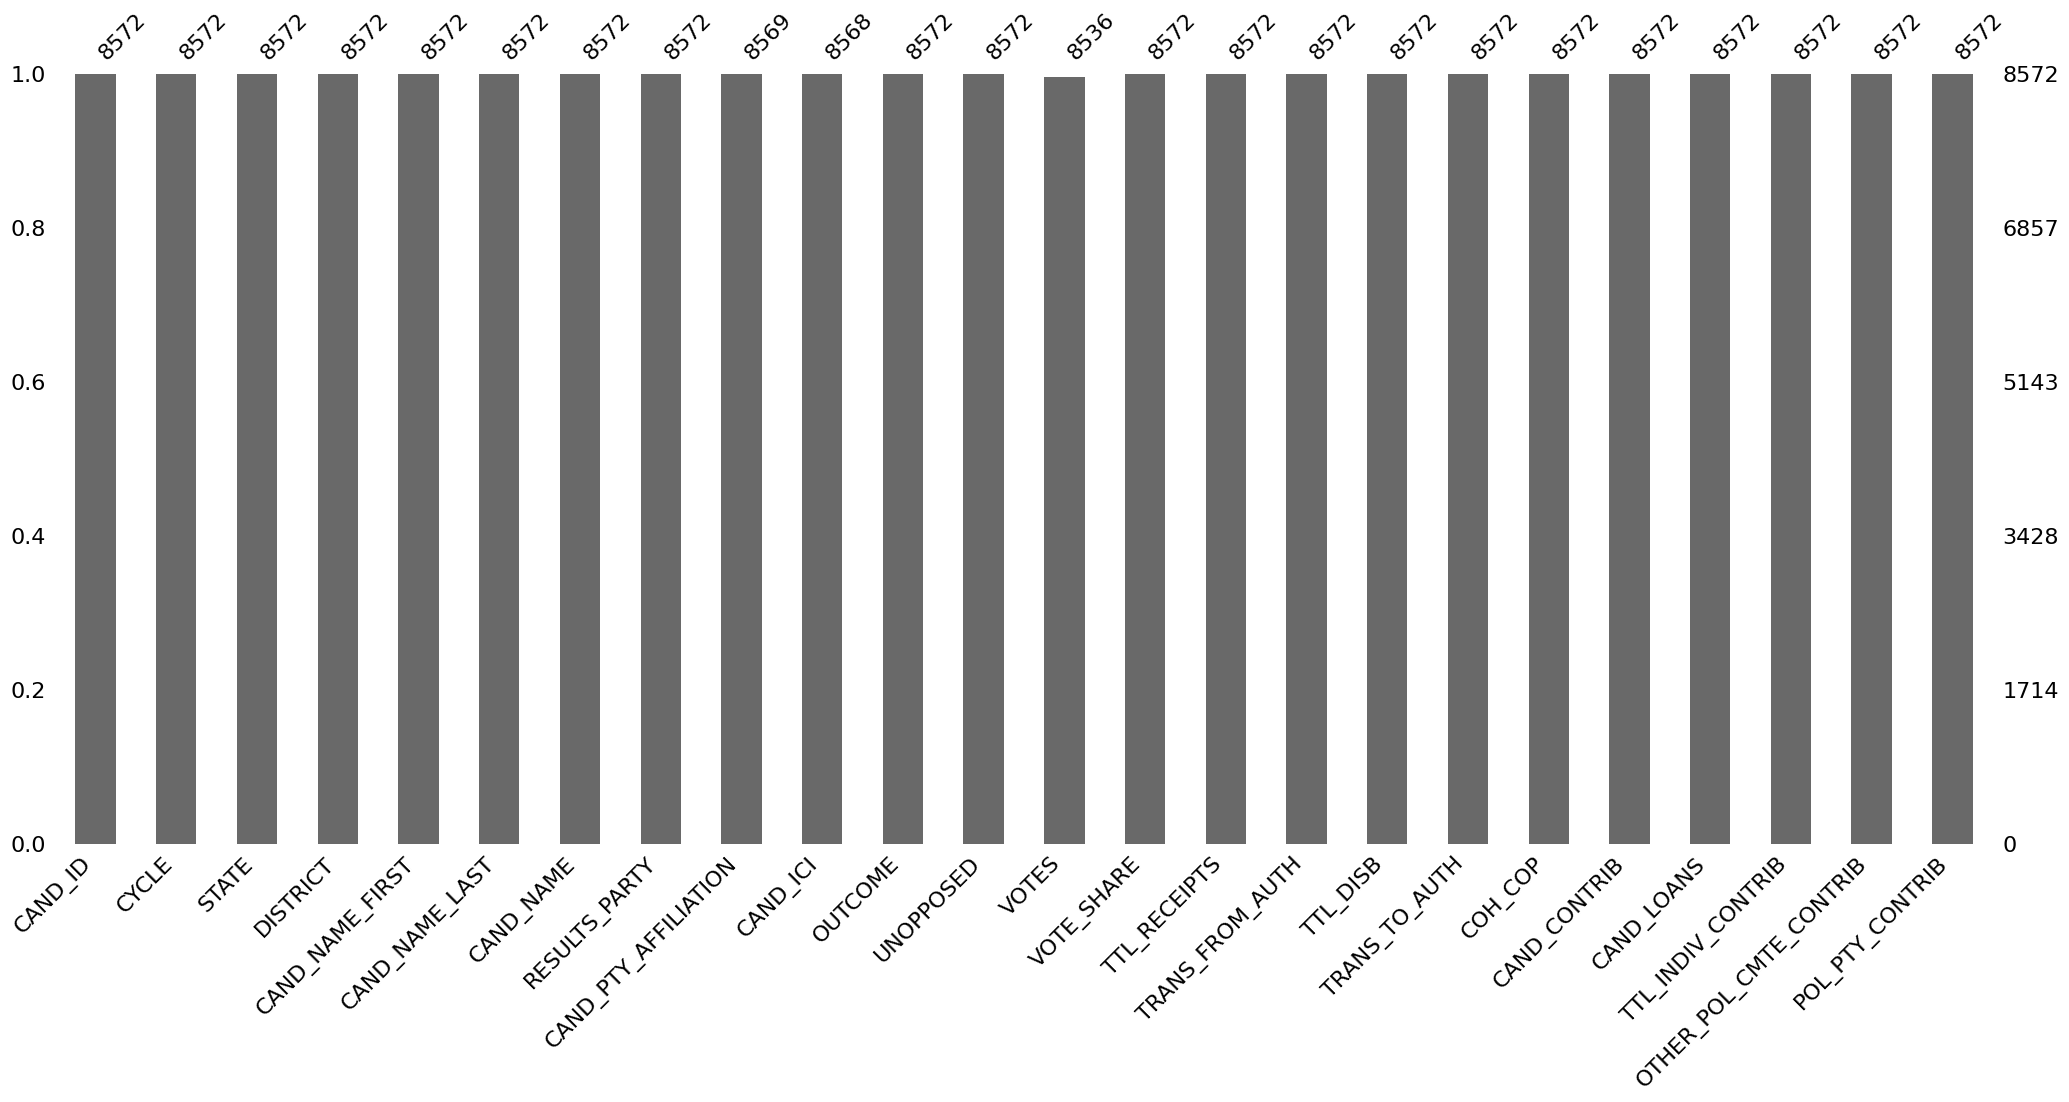

In [65]:
display(df.isna().sum())
msno.bar(df)    

In [66]:
print('Null incumbency: ')
display(df[df['CAND_ICI'].isna()])

df.loc[df.index[5158], 'CAND_ICI'] = 'C'
df.loc[df.index[5177], 'CAND_ICI'] = 'C'
df.loc[df.index[6539], 'CAND_ICI'] = 'C'
df.loc[df.index[6725], 'CAND_ICI'] = 'C'

print('Null incumbency afer manual correction: ')
display(df[df['CAND_ICI'].isna()])

Null incumbency: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,TTL_RECEIPTS,TRANS_FROM_AUTH,TTL_DISB,TRANS_TO_AUTH,COH_COP,CAND_CONTRIB,CAND_LOANS,TTL_INDIV_CONTRIB,OTHER_POL_CMTE_CONTRIB,POL_PTY_CONTRIB
5158,H6AK00235,2016,AK,0,Steve,Lindbeck,"LINDBECK, STEVE",DEM,DEM,NaN,...,1102309.77,0.0,1098098.09,0.0,4211.68,17555.0,0.0,999400.98,67074.61,5000.0
5177,H6AS00031,2016,AS,0,Vaitinasa Salu,Hunkin-Finau,"HUNKIN-FINAU, VAITINASA SALU",DEM,DEM,NaN,...,41670.00,0.0,38167.44,0.0,4561.00,12900.0,0.0,20555.00,0.00,8215.0
6539,H6OH09073,2018,OH,1,Dirk,Kubala,"KUBALA, DIRK",LIB,LIB,NaN,...,2836.00,0.0,2836.00,0.0,0.00,511.0,1625.0,700.00,0.00,0.0
6725,H0TX27038,2018,TX,27,James,Duerr,"DUERR, JAMES MATTHEW",IND,REP,NaN,...,33258.30,0.0,65154.80,0.0,-36661.30,0.0,21111.3,12147.00,0.00,0.0


Null incumbency afer manual correction: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,TTL_RECEIPTS,TRANS_FROM_AUTH,TTL_DISB,TRANS_TO_AUTH,COH_COP,CAND_CONTRIB,CAND_LOANS,TTL_INDIV_CONTRIB,OTHER_POL_CMTE_CONTRIB,POL_PTY_CONTRIB


In [67]:
print('NaN votes: ', df['VOTES'].isna().sum())

df = df[df['UNOPPOSED']==False][df['VOTE_SHARE']<0.999]

print('NaN votes after dropping unopposed races: ', df['VOTES'].isna().sum())

df.reset_index(drop=True, inplace=True)

NaN votes:  36
NaN votes after dropping unopposed races:  0


In [68]:
print('Null party affiliation: ')
display(df[df['CAND_PTY_AFFILIATION'].isna()])

df.loc[df.index[1638], 'CAND_PTY_AFFILIATION'] = 'IND'
df.loc[df.index[1666], 'CAND_PTY_AFFILIATION'] = 'IND'
df.loc[df.index[2251], 'CAND_PTY_AFFILIATION'] = 'IND'

print('Null party affiliation instances after manual correction: ')
display(df[df['CAND_PTY_AFFILIATION'].isna()])

Null party affiliation: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,TTL_RECEIPTS,TRANS_FROM_AUTH,TTL_DISB,TRANS_TO_AUTH,COH_COP,CAND_CONTRIB,CAND_LOANS,TTL_INDIV_CONTRIB,OTHER_POL_CMTE_CONTRIB,POL_PTY_CONTRIB
1602,H6WV01061,2006,WV,1,David,Moran,"MORAN, DAVID DUNSTAN",W,NaN,C,...,2495.00,0.0,1613.00,0.0,882.00,0.00,0.0,0.0,0.0,0.0
1630,H8AZ01120,2008,AZ,1,Brent,Maupin,"MAUPIN, BRENT GEER",I,NaN,O,...,30491.00,0.0,30467.00,0.0,0.00,23450.00,931.0,6110.0,0.0,0.0
2206,H8OH15092,2008,OH,15,Don Elijah,Eckhart,"ECKHART, DON ELIJAH",I,NaN,C,...,34173.98,0.0,33597.03,0.0,576.95,30837.98,0.0,2761.0,0.0,0.0


Null party affiliation instances after manual correction: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,TTL_RECEIPTS,TRANS_FROM_AUTH,TTL_DISB,TRANS_TO_AUTH,COH_COP,CAND_CONTRIB,CAND_LOANS,TTL_INDIV_CONTRIB,OTHER_POL_CMTE_CONTRIB,POL_PTY_CONTRIB
1602,H6WV01061,2006,WV,1,David,Moran,"MORAN, DAVID DUNSTAN",W,NaN,C,...,2495.00,0.0,1613.00,0.0,882.00,0.00,0.0,0.0,0.0,0.0
1630,H8AZ01120,2008,AZ,1,Brent,Maupin,"MAUPIN, BRENT GEER",I,NaN,O,...,30491.00,0.0,30467.00,0.0,0.00,23450.00,931.0,6110.0,0.0,0.0
2206,H8OH15092,2008,OH,15,Don Elijah,Eckhart,"ECKHART, DON ELIJAH",I,NaN,C,...,34173.98,0.0,33597.03,0.0,576.95,30837.98,0.0,2761.0,0.0,0.0


In [ ]:
df.columns = df.columns.str.lower()

df.rename(columns={"cand_ici": "incumbency"}, inplace=True)

numeric_cols = [ "ttl_receipts", "ttl_disb", "coh_cop", "ttl_indiv_contrib", "other_pol_cmte_contrib", "pol_pty_contrib", ]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

receipts = df["ttl_receipts"].replace(0, np.nan)

df["log1p_ttl_receipts"] = np.log1p(df["ttl_receipts"])
df["burn_rate"] = df["ttl_disb"] / receipts
df["cash_ratio"] = df["coh_cop"] / receipts
df["indiv_share"] = df["ttl_indiv_contrib"] / receipts
df["other_cmte_share"] = df["other_pol_cmte_contrib"] / receipts
df["party_share"] = df["pol_pty_contrib"] / receipts

In [70]:
derived_cols = [
    "log1p_ttl_receipts",
    "burn_rate",
    "cash_ratio",
    "indiv_share",
    "other_cmte_share",
    "party_share",
]

print(df[derived_cols].isna().mean().sort_values())
print(df[derived_cols].describe())

log1p_ttl_receipts    0.000000
burn_rate             0.005689
cash_ratio            0.005689
indiv_share           0.005689
other_cmte_share      0.005689
party_share           0.005689
dtype: float64
       log1p_ttl_receipts    burn_rate   cash_ratio  indiv_share  \
count         8437.000000  8389.000000  8389.000000  8389.000000   
mean            12.830219     1.021831     0.300756     0.589650   
std              2.257642     3.824602     8.101471     0.370656   
min              0.000000    -0.046830    -4.138250     0.000000   
25%             11.514139     0.906298     0.005983     0.411391   
50%             13.668956     0.986121     0.041912     0.587187   
75%             14.331167     1.000131     0.247939     0.789645   
max             17.457315   333.866667   738.226667    25.800000   

       other_cmte_share  party_share  
count       8389.000000  8389.000000  
mean           0.256634     0.010672  
std            0.236385     0.047353  
min            0.000000     0.

In [ ]:
weird = (df.loc[
        (df["burn_rate"] > 5) |
        (df["cash_ratio"] > 5) |
        (df["indiv_share"] > 1.5) |
        (df["other_cmte_share"] > 1.5) |
        (df["party_share"] > 1),
        ["cycle", "state", "district", "cand_id","ttl_receipts", "ttl_disb", "coh_cop","ttl_indiv_contrib", "other_pol_cmte_contrib", "pol_pty_contrib",
            "burn_rate", "cash_ratio", "indiv_share", "other_cmte_share", "party_share"]].copy())

flags = []
flags.append(np.where(weird["burn_rate"] > 5, "burn_rate>5", ""))
flags.append(np.where(weird["cash_ratio"] > 5, "cash_ratio>5", ""))
flags.append(np.where(weird["indiv_share"] > 1.5, "indiv_share>1.5", ""))
flags.append(np.where(weird["other_cmte_share"] > 1.5, "other_cmte_share>1.5", ""))
flags.append(np.where(weird["party_share"] > 1, "party_share>1", ""))

weird["flag_reason"] = [
    "; ".join(x for x in row if x)
    for row in zip(*flags)
]

weird = weird.sort_values(["cycle", "state", "district", "cand_id"]).round(3)

display(weird.head(50))
print(len(weird))
print('Null receipts: ', (df["ttl_receipts"] == 0).sum())

,cycle,state,district,cand_id,ttl_receipts,ttl_disb,coh_cop,ttl_indiv_contrib,other_pol_cmte_contrib,pol_pty_contrib,burn_rate,cash_ratio,indiv_share,other_cmte_share,party_share,flag_reason
111,2004,CA,48,H0CA47034,40.00,1994.00,0.00,40.00,0.00,0.0,49.850,0.000,1.000,0.000,0.0,burn_rate>5
185,2004,FL,21,H4FL21047,7208.00,12719.00,884.00,13437.00,0.00,0.0,1.765,0.123,1.864,0.000,0.0,indiv_share>1.5
1955,2008,MA,10,H2MA11060,117099.51,1217880.80,932910.63,33555.25,133048.02,0.0,10.400,7.967,0.287,1.136,0.0,burn_rate>5; cash_ratio>5
2755,2010,IN,6,H6IN06149,115.00,7603.91,0.00,115.00,0.00,0.0,66.121,0.000,1.000,0.000,0.0,burn_rate>5
3447,2012,CA,20,H8CA17089,100.00,6616.61,5607.72,0.00,0.00,100.0,66.166,56.077,0.000,0.000,1.0,burn_rate>5; cash_ratio>5
4206,2012,WA,9,H8WA09047,1818.00,6313.41,50174.78,1818.00,0.00,0.0,3.473,27.599,1.000,0.000,0.0,cash_ratio>5
4567,2014,LA,2,H2LA02107,250.00,4191.00,0.00,6450.00,0.00,0.0,16.764,0.000,25.800,0.000,0.0,burn_rate>5; indiv_share>1.5
4914,2014,TN,8,H2TN08077,1.50,500.80,1107.34,0.00,0.00,0.0,333.867,738.227,0.000,0.000,0.0,burn_rate>5; cash_ratio>5
5161,2016,CA,34,H6CA34229,20.00,1.80,518.20,20.00,0.00,0.0,0.090,25.910,1.000,0.000,0.0,cash_ratio>5
6331,2018,NJ,2,H8NJ02281,40.00,530.53,-165.53,40.00,0.00,0.0,13.263,-4.138,1.000,0.000,0.0,burn_rate>5


15
Null receipts:  48


In [72]:
# In light of the foregoing, in order to work with unambiguous derived features for each campaign, we must drop de minimis campaigns by a receipts threshold, namely $5000 USD
# This is justified in light of the following:
# 1) Very low-receipt campaigns create unstable finance ratios because the denominator is tiny

# 2) In electoral research, it is quite standard for analysts to restrict data to 'serious' contenders rather than treat all ballot-listed candidates as equally informative, 
# providing strong precedent (cf. Thomsen's Competition in Congressional Elections (https://www.cambridge.org/core/journals/american-political-science-review/article/competition-in-congressional-elections-money-versus-votes/F84C395D7155C9C0D82971BC0BFC75E8)
# and Sanbonmatsu & Gothreau's Money Matters in the Fifty States (https://cawp.rutgers.edu/sites/default/files/2021-12/money-matters-in-the-states_a11y.pdf))

# 3) In addition to the above, the $5,000 cutoff is in fact the FEC trigger at which federal candidate registration/reporting obligations attach, hence highly non-arbitrary

 
# Sensitivity check for to compare how many rows survive at $1000 versus $5000 

for floor in [1000, 5000]:
    n = (df["ttl_receipts"] >= floor).sum()
    pct = 100 * n / len(df)
    print(f"Number of observations with ttl_receipts >= ${floor:,.0f}: {n} rows ({pct:.2f}%)")
    
df_model = df.loc[df["ttl_receipts"] >= 5000]
df_model.isna().sum().sum()

Number of observations with ttl_receipts >= $1,000: 8308 rows (98.47%)
Number of observations with ttl_receipts >= $5,000: 8129 rows (96.35%)


np.int64(2)

In [ ]:
ratio_cols = [ "burn_rate", "cash_ratio", "indiv_share", "other_cmte_share", "party_share", ]

for col in ratio_cols:
    lo = df_model[col].quantile(0.01)
    hi = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower=lo, upper=hi)

print("Original rows:", len(df))
print("Model rows:", len(df_model))
print("Dropped rows:", len(df) - len(df_model))
print()
summary = (df_model[["log1p_ttl_receipts", "burn_rate", "cash_ratio","indiv_share", "other_cmte_share", "party_share"]].describe().T.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "SD",
        "min": "Min",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Max"}).round(3))

summary

Original rows: 8437
Model rows: 8129
Dropped rows: 308



,N,Mean,SD,Min,Q1,Median,Q3,Max
log1p_ttl_receipts,8129.0,13.084,1.794,8.517,11.842,13.736,14.356,17.457
burn_rate,8129.0,0.952,0.160,0.417,0.908,0.986,1.000,1.505
cash_ratio,8129.0,0.191,0.313,-0.058,0.006,0.042,0.247,1.610
indiv_share,8129.0,0.587,0.242,0.013,0.414,0.586,0.785,1.000
other_cmte_share,8129.0,0.264,0.234,0.000,0.034,0.219,0.459,0.792
party_share,8129.0,0.008,0.027,0.000,0.000,0.000,0.003,0.186


In [74]:
df_model.isna().sum().sum()

np.int64(2)

In [75]:
df_model[df_model['ttl_receipts']<5000]

,cand_id,cycle,state,district,cand_name_first,cand_name_last,cand_name,results_party,cand_pty_affiliation,incumbency,...,cand_loans,ttl_indiv_contrib,other_pol_cmte_contrib,pol_pty_contrib,log1p_ttl_receipts,burn_rate,cash_ratio,indiv_share,other_cmte_share,party_share


In [76]:
df_model.columns

Index(['cand_id', 'cycle', 'state', 'district', 'cand_name_first',
       'cand_name_last', 'cand_name', 'results_party', 'cand_pty_affiliation',
       'incumbency', 'outcome', 'unopposed', 'votes', 'vote_share',
       'ttl_receipts', 'trans_from_auth', 'ttl_disb', 'trans_to_auth',
       'coh_cop', 'cand_contrib', 'cand_loans', 'ttl_indiv_contrib',
       'other_pol_cmte_contrib', 'pol_pty_contrib', 'log1p_ttl_receipts',
       'burn_rate', 'cash_ratio', 'indiv_share', 'other_cmte_share',
       'party_share'],
      dtype='str')

In [77]:
df_model[df_model['cand_pty_affiliation'] != df_model['results_party']]


,cand_id,cycle,state,district,cand_name_first,cand_name_last,cand_name,results_party,cand_pty_affiliation,incumbency,...,cand_loans,ttl_indiv_contrib,other_pol_cmte_contrib,pol_pty_contrib,log1p_ttl_receipts,burn_rate,cash_ratio,indiv_share,other_cmte_share,party_share
0,H6AK00045,2004,AK,0,Alvin A.,Anders,"YOUNG, DON E",LBT,REP,I,...,0.00,1491130.73,928658.63,392.00,14.724952,0.703966,0.764646,0.600552,0.374016,0.000158
43,H4CA05232,2004,CA,5,Pat,Driscoll,"DRISCOLL, PATRICK WILLIAM",GRN,GRE,C,...,0.00,11610.73,200.00,922.25,9.465582,0.812318,0.443132,0.899587,0.015496,0.071455
54,H4CA11081,2004,CA,11,Gerald (Jerry) M.,McNerney,"MCNERNEY, GERALD MARK",W,DEM,C,...,0.00,137669.41,16110.00,0.00,11.963298,0.986072,0.013928,0.877498,0.102684,0.000000
56,H4CA12071,2004,CA,12,Pat,Gray,"GRAY, PAT",GRN,GRE,C,...,4000.00,39662.00,0.00,1500.00,10.778039,0.931811,0.068210,0.827067,0.000000,0.031279
58,H4CA13079,2004,CA,13,George I.,Bruno,"BRUNO, GEORGE IR JR",REP,UNK,C,...,0.00,23815.06,5000.00,0.00,10.356655,1.013348,0.000000,0.756881,0.158908,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8360,H4TX25083,2022,TX,38,Joel,DeJean,"DEJEAN, JOEL F.",IND,DEM,O,...,0.00,12894.00,0.00,0.00,9.616532,0.984755,0.015245,0.859033,0.000000,0.000000
8364,H2UT02472,2022,UT,2,JayMac,McFarland,"MCFARLAND, JAY JAYMAC",UUP,OTH,C,...,0.00,85217.86,0.00,0.00,11.352978,1.000000,0.000000,1.000000,0.000000,0.000000
8369,H2UT04106,2022,UT,4,January,Walker,"WALKER, JANUARY",UUP,OTH,C,...,14697.28,22236.34,0.00,5000.00,10.643867,1.000000,0.000000,0.530275,0.000000,0.119236
8395,H2VT01100,2022,VT,0,Liam,Madden,"MADDEN, LIAM",REP,IND,O,...,0.00,47659.85,0.00,0.00,10.771866,0.883651,0.116349,1.000000,0.000000,0.000000


In [78]:
major = {"DEM", "REP"}

serious_party_mismatch = df_model[
    df_model["results_party"].isin(major)
    & df_model["cand_pty_affiliation"].isin(major)
    & (df_model["results_party"] != df_model["cand_pty_affiliation"])
]

print(len(serious_party_mismatch))
print(
    serious_party_mismatch[
        ["cycle", "state", "district", "cand_id", "cand_name", "results_party", "cand_pty_affiliation"]
    ].sort_values(["cycle", "state", "district"]).head(50)
)

18
      cycle state  district    cand_id                   cand_name  \
1013   2006    HI         1  H6HI02301                  MENOR, RON   
1231   2006    NC         4  H6NC04128             ACUFF, STEVEN D   
1232   2006    NC         4  H6NC04037                PRICE, DAVID   
1618   2008    AL         5  H8AL05109       GRIFFITH, PARKER REP.   
2060   2008    NC         5  H6NC04037                PRICE, DAVID   
2098   2008    NJ         5  H8NJ05094           SHULMAN, DENNIS G   
3027   2010    NY         5  H0NY05062               MILANO, JAMES   
3875   2012    NJ         4  H8NJ04014       SMITH, CHRISTOPHER H.   
3876   2012    NJ         4  H2NJ04165           FROELICH, BRIAN P   
3917   2012    NY         5  H2NY05084        JENNINGS, ALLAN W JR   
6164   2018    KY         6  H8KY02098   SESSIONS, RANE EIR OLIVIA   
6475   2018    PA         3  H6PA01165                 LEIB, BRYAN   
7417   2020    TN         7  H0TN07255             SREEPADA, KIRAN   
7628   2022    CA

In [ ]:
keep = {"DEM", "REP", "LIB", "GRN", "IND"}

df_model["party"] = np.where( df_model["results_party"].isin(keep), df_model["results_party"], "OTH" )

df_model.drop(columns=['cand_pty_affiliation', 'results_party'], inplace=True)

In [80]:
# final dedup!

keys = ["cand_id", "cycle", "state", "district"]

dups = df_model.duplicated(subset=keys, keep=False)

print(dups.sum())
print(df_model.loc[dups, keys].sort_values(keys).head(20))

0
Empty DataFrame
Columns: [cand_id, cycle, state, district]
Index: []


In [81]:
df_model.to_parquet('house_clean.parquet', index=False)